In [1]:
# ===== CELL 1: Install & Auth =====

!pip install earthengine-api geemap -q

import ee
import geemap
import pandas as pd
import numpy as np
from google.colab import drive

ee.Authenticate()
ee.Initialize(project='triple-name-491719-c9')
drive.mount('/content/drive')
print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 13.3 MB/s eta 0:00:00
Mounted at /content/drive
Ready.


In [2]:
# ===== CELL 2: Build Sentinel-2 Time Series =====

BANDS      = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
BAND_NAMES = ['Blue','Green','Red','RedEdge1','RedEdge2',
              'RedEdge3','NIR','RedEdge4','SWIR1','SWIR2']

def mask_clouds(image):
    scl  = image.select('SCL')
    mask = (scl.neq(3).And(scl.neq(8))
               .And(scl.neq(9)).And(scl.neq(10)))
    return (image.select(BANDS)
                 .updateMask(mask)
                 .divide(10000)
                 .copyProperties(image, ['system:time_start']))

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate('2021-01-01', '2021-12-31')
        .select(BANDS + ['SCL'])
        .map(mask_clouds))

def make_composite(step):
    step     = ee.Number(step)
    start    = ee.Date('2021-01-01').advance(step.multiply(10), 'day')
    end      = start.advance(10, 'day')
    step_str = step.add(1).format('%02d')
    composite = s2.filterDate(start, end).median()
    has_data  = (composite.select('B2').mask()
                          .unmask(0)
                          .rename(ee.String('mask_t').cat(step_str)))
    composite = composite.unmask(0)
    new_names = ee.List(BAND_NAMES).map(
        lambda b: ee.String(b).cat('_t').cat(step_str)
    )
    return composite.rename(new_names).addBands(has_data)

time_steps = ee.List.sequence(0, 35)
stacked    = ee.ImageCollection(time_steps.map(make_composite)).toBands()
print('Sentinel-2 time series ready.')

Sentinel-2 time series ready.


In [3]:
# ===== CELL 3: Load CDL 2021 =====

cdl         = (ee.ImageCollection('USDA/NASS/CDL')
                 .filterDate('2021-01-01', '2021-12-31')
                 .first())
crop_labels = cdl.select('cropland')
confidence  = cdl.select('confidence')

print('CDL 2021 loaded.')

CDL 2021 loaded.


In [4]:
# ===== CELL 4: Sampling functions =====

N = 600   # samples per class per zone — small enough for GEE

def sample_class(region, cdl_code, label, n, seed):
    mask  = crop_labels.eq(cdl_code).And(confidence.gte(80))
    image = (stacked
             .updateMask(mask)
             .addBands(ee.Image.constant(label)
                               .rename('crop_label').toInt()))
    return image.sample(
        region=region, scale=30,
        numPixels=n, seed=seed, geometries=False
    )

def sample_others(region, exclude_codes, label, n, seed):
    mask = crop_labels.gte(1).And(crop_labels.lte(254))
    for code in exclude_codes:
        mask = mask.And(crop_labels.neq(code))
    mask  = mask.And(confidence.gte(80))
    image = (stacked
             .updateMask(mask)
             .addBands(ee.Image.constant(label)
                               .rename('crop_label').toInt()))
    return image.sample(
        region=region, scale=30,
        numPixels=n, seed=seed, geometries=False
    )

def launch_export(collection, filename):
    task = ee.batch.Export.table.toDrive(
        collection     = collection,
        description    = filename,
        folder         = 'MCTNet_Dataset',
        fileNamePrefix = filename,
        fileFormat     = 'CSV'
    )
    task.start()
    print(f'Launched: {filename}')
    return task

print(f'Functions ready. N={N} per class per zone.')

Functions ready. N=600 per class per zone.


In [5]:
# ===== CELL 5: Arkansas Zone A — Northeast Delta =====
# Main crops here: soybeans, rice, corn
# [west, south, east, north]

AR_A = ee.Geometry.Rectangle([-91.5, 35.2, -90.2, 36.0])

ar_a_collection = (
    sample_class (AR_A, 5, 0, N, seed=101)   # soybeans
    .merge(sample_class (AR_A, 3, 1, N, seed=102))   # rice
    .merge(sample_class (AR_A, 1, 2, N, seed=103))   # corn
    .merge(sample_class (AR_A, 2, 3, N, seed=104))   # cotton
    .merge(sample_others(AR_A, [5,3,1,2], 4, N, seed=105))
)

task_ar_a = launch_export(ar_a_collection, 'arkansas_zoneA')

Launched: arkansas_zoneA


In [6]:
# ===== CELL 6: Arkansas Zone B — Central Delta =====
# Main crops here: soybeans, cotton

AR_B = ee.Geometry.Rectangle([-91.8, 34.4, -90.5, 35.2])

ar_b_collection = (
    sample_class (AR_B, 5, 0, N, seed=201)
    .merge(sample_class (AR_B, 3, 1, N, seed=202))
    .merge(sample_class (AR_B, 1, 2, N, seed=203))
    .merge(sample_class (AR_B, 2, 3, N, seed=204))
    .merge(sample_others(AR_B, [5,3,1,2], 4, N, seed=205))
)

task_ar_b = launch_export(ar_b_collection, 'arkansas_zoneB')

Launched: arkansas_zoneB


In [7]:
# ===== CELL 7: Arkansas Zone C — South Delta =====
# Main crops here: soybeans, cotton, corn

AR_C = ee.Geometry.Rectangle([-91.5, 33.5, -90.2, 34.4])

ar_c_collection = (
    sample_class (AR_C, 5, 0, N, seed=301)
    .merge(sample_class (AR_C, 3, 1, N, seed=302))
    .merge(sample_class (AR_C, 1, 2, N, seed=303))
    .merge(sample_class (AR_C, 2, 3, N, seed=304))
    .merge(sample_others(AR_C, [5,3,1,2], 4, N, seed=305))
)

task_ar_c = launch_export(ar_c_collection, 'arkansas_zoneC')

Launched: arkansas_zoneC


In [8]:
# ===== CELL 8: Arkansas Zone D — West Delta =====

AR_D = ee.Geometry.Rectangle([-92.8, 33.8, -91.5, 34.8])

ar_d_collection = (
    sample_class (AR_D, 5, 0, N, seed=401)
    .merge(sample_class (AR_D, 3, 1, N, seed=402))
    .merge(sample_class (AR_D, 1, 2, N, seed=403))
    .merge(sample_class (AR_D, 2, 3, N, seed=404))
    .merge(sample_others(AR_D, [5,3,1,2], 4, N, seed=405))
)

task_ar_d = launch_export(ar_d_collection, 'arkansas_zoneD')

Launched: arkansas_zoneD


In [9]:
# ===== Arkansas Zone E — Extra zone for more samples =====

AR_E = ee.Geometry.Rectangle([-92.0, 35.5, -90.8, 36.3])

N = 600  # make sure this is defined, if not add this line

ar_e_collection = (
    sample_class (AR_E, 5, 0, N, seed=501)   # soybeans
    .merge(sample_class (AR_E, 3, 1, N, seed=502))   # rice
    .merge(sample_class (AR_E, 1, 2, N, seed=503))   # corn
    .merge(sample_class (AR_E, 2, 3, N, seed=504))   # cotton
    .merge(sample_others(AR_E, [5,3,1,2], 4, N, seed=505))
)

task_ar_e = launch_export(ar_e_collection, 'arkansas_zoneE')
print('Arkansas Zone E launched.')

Launched: arkansas_zoneE
Arkansas Zone E launched.


In [10]:
# ===== CELL 9: Monitor =====
# Run this cell every few minutes

tasks = [
    (task_ar_a, 'AR Zone A'),
    (task_ar_b, 'AR Zone B'),
    (task_ar_c, 'AR Zone C'),
    (task_ar_d, 'AR Zone D'),
]

for task, name in tasks:
    s = task.status()
    print(f'{name}: {s["state"]}')
    if s['state'] == 'FAILED':
        print(f'  --> Error: {s.get("error_message", "unknown")}')

AR Zone A: COMPLETED
AR Zone B: COMPLETED
AR Zone C: COMPLETED
AR Zone D: COMPLETED


In [11]:
# ===== CELL 10: Merge + Balance (run AFTER all COMPLETED) =====

import os

base = '/content/drive/MyDrive/MCTNet_Dataset/'

AR_NAMES = {0:'Soybeans', 1:'Rice', 2:'Corn', 3:'Cotton', 4:'Others'}

def load_and_clean(path):
    df = pd.read_csv(path)
    df = df.drop(columns=['system:index', '.geo'], errors='ignore')
    rename_map = {}
    for col in df.columns:
        parts = col.split('_')
        if parts[0].isdigit():
            rename_map[col] = '_'.join(parts[1:])
    return df.rename(columns=rename_map)

# Load all zones
ar_parts = []
for zone in ['A', 'B', 'C', 'D', 'E']:   # add E here
    path = f'{base}arkansas_zone{zone}.csv'
    if os.path.exists(path):
        part = load_and_clean(path)
        ar_parts.append(part)
        print(f'Zone {zone}: {len(part)} rows')
        print(f'  Distribution: {dict(part["crop_label"].value_counts().sort_index())}')
    else:
        print(f'Zone {zone}: NOT FOUND')

if not ar_parts:
    print('ERROR: No files found. Check exports completed in GEE task manager.')
else:
    ar_merged = pd.concat(ar_parts, ignore_index=True)
    print(f'\nMerged total: {len(ar_merged)} rows')
    print('Distribution after merge:')
    print(ar_merged['crop_label'].value_counts().sort_index())

Zone A: 448 rows
  Distribution: {0: np.int64(147), 1: np.int64(90), 2: np.int64(34), 3: np.int64(40), 4: np.int64(137)}
Zone B: 411 rows
  Distribution: {0: np.int64(129), 1: np.int64(44), 2: np.int64(51), 3: np.int64(26), 4: np.int64(161)}
Zone C: 474 rows
  Distribution: {0: np.int64(228), 1: np.int64(20), 2: np.int64(40), 3: np.int64(25), 4: np.int64(161)}
Zone D: 356 rows
  Distribution: {0: np.int64(44), 1: np.int64(23), 2: np.int64(23), 3: np.int64(10), 4: np.int64(256)}
Zone E: 422 rows
  Distribution: {0: np.int64(56), 1: np.int64(69), 2: np.int64(11), 4: np.int64(286)}

Merged total: 2111 rows
Distribution after merge:
crop_label
0     604
1     246
2     159
3     101
4    1001
Name: count, dtype: int64


In [12]:
# ===== CELL 11: Balance and save =====

def balance(df, label_col='crop_label'):
    counts    = df[label_col].value_counts()
    min_count = counts.min()
    print(f'Min class size: {min_count}')
    parts = []
    for cls in sorted(df[label_col].unique()):
        subset = df[df[label_col] == cls].drop_duplicates()
        n      = min(min_count, len(subset))
        parts.append(subset.sample(n=n, random_state=42))
    result = pd.concat(parts).sample(frac=1, random_state=42).reset_index(drop=True)
    print('Balanced distribution:')
    for k, v in result[label_col].value_counts().sort_index().items():
        print(f'  {AR_NAMES.get(k, k)}: {v}')
    print(f'Total: {len(result)}')
    return result

ar_final = balance(ar_merged)
ar_final.to_csv(f'{base}arkansas_balanced_final.csv', index=False)
print('\nSaved: arkansas_balanced_final.csv')

Min class size: 101
Balanced distribution:
  Soybeans: 101
  Rice: 101
  Corn: 101
  Cotton: 101
  Others: 101
Total: 505

Saved: arkansas_balanced_final.csv


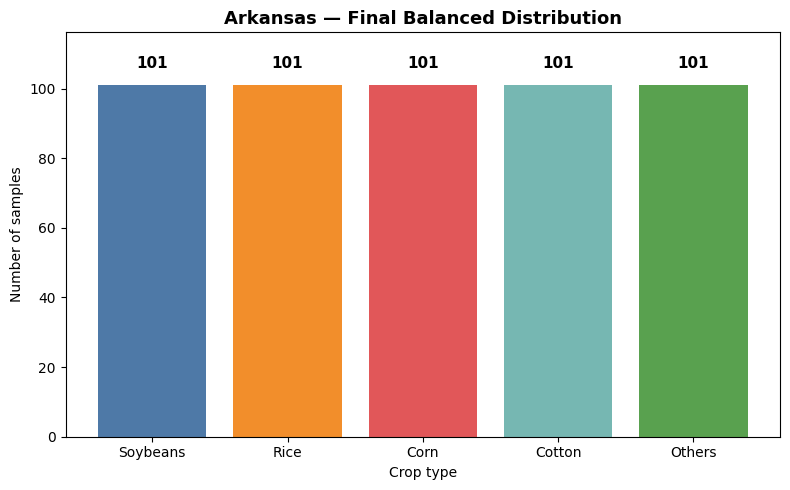

Total samples: 505


In [13]:
# ===== CELL 12: Plot =====

import matplotlib.pyplot as plt

colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f']
counts = ar_final['crop_label'].value_counts().sort_index()
labels = [AR_NAMES.get(i, str(i)) for i in counts.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, counts.values, color=colors[:len(labels)])
ax.set_title('Arkansas — Final Balanced Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of samples')
ax.set_xlabel('Crop type')
ax.set_ylim(0, max(counts.values) * 1.15)
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{base}arkansas_balanced_final.png', dpi=150)
plt.show()
print(f'Total samples: {len(ar_final)}')